# LAB 1 — Notebook 02: Regression Paradigm
## Mobile Money Fraud Detection | EEF606 | University of Buea

---
**Prerequisite:** Run `lab1_00_eda_analysis.ipynb` first.

### What is Regression in this context?
Instead of asking **'Is this fraud? (yes/no)'**, regression asks:
- **'What is the probability that this is fraud?'** (0.0 → 1.0)
- **'How suspicious is this transaction on a continuous scale?'**
- **'Can we predict the transaction amount from other features?'**

We explore **three regression formulations**:
1. **Fraud probability prediction** — treat isFraud as a continuous target (logistic/ridge)
2. **Amount prediction** — regress on transaction amount (feature behaviour study)
3. **Fraud risk score** — build a continuous risk index using regression output

### Why regression matters for fraud:
Regression gives a SCORE not just a label. A score of 0.97 is more actionable
than 'fraud=1' — it tells you HOW CONFIDENT the system is.
Real fraud systems (VISA, Mastercard) produce risk scores, not binary labels.

In [1]:
# ══════════════════════════════════════════════════════════
# CELL 1 — Imports
# WHY statsmodels IN ADDITION TO sklearn:
# sklearn's Logistic Regression is optimised for PREDICTION.
# statsmodels' Logit is optimised for INFERENCE — it gives
# p-values, confidence intervals, and significance tests
# for each feature. In academia (and court cases), you need
# to PROVE a feature matters, not just use it.
# ══════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection   import train_test_split
from sklearn.preprocessing     import RobustScaler
from sklearn.linear_model      import (LinearRegression, Ridge, Lasso,
                                         ElasticNet, LogisticRegression)
from sklearn.ensemble          import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics           import (mean_squared_error, mean_absolute_error,
                                        r2_score, roc_auc_score, average_precision_score)
import statsmodels.api as sm
from imblearn.over_sampling    import SMOTE

plt.rcParams.update({'figure.dpi':120,'figure.facecolor':'white',
                     'axes.facecolor':'#F8F9FA','axes.grid':True,'grid.alpha':0.4})
SEED = 42
print('✅ Imports loaded')

✅ Imports loaded


In [2]:
# ══════════════════════════════════════════════════════════
# CELL 2 — Load Data
# ══════════════════════════════════════════════════════════
df = pd.read_csv('paysim_features.csv')
df = df.drop(columns=[c for c in ['isFlaggedFraud'] if c in df.columns])

X_all = df.drop(columns=['isFraud'])
y_fraud = df['isFraud']          # binary target (for logistic / probability regression)
y_amount = np.log1p(df['amount']) if 'amount' in df.columns else np.log1p(X_all.get('amount', X_all.iloc[:,0]))

X_train, X_test, yf_train, yf_test = train_test_split(
    X_all, y_fraud, test_size=0.2, random_state=SEED, stratify=y_fraud)

scaler = RobustScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

smote = SMOTE(random_state=SEED)
X_tr_sm, yf_tr_sm = smote.fit_resample(X_tr_sc, yf_train)

print(f'Data loaded: {X_all.shape}  |  Fraud: {y_fraud.sum()} ({y_fraud.mean()*100:.2f}%)')

Data loaded: (300000, 19)  |  Fraud: 181 (0.06%)


PART A — Logistic Regression (Probability Output)
         ROC-AUC  PR-AUC
C                       
0.001     0.9431  0.4018
0.010     0.9598  0.4118
0.100     0.9650  0.4015
1.000     0.9647  0.4101
10.000    0.9648  0.4057
100.000   0.9644  0.4103


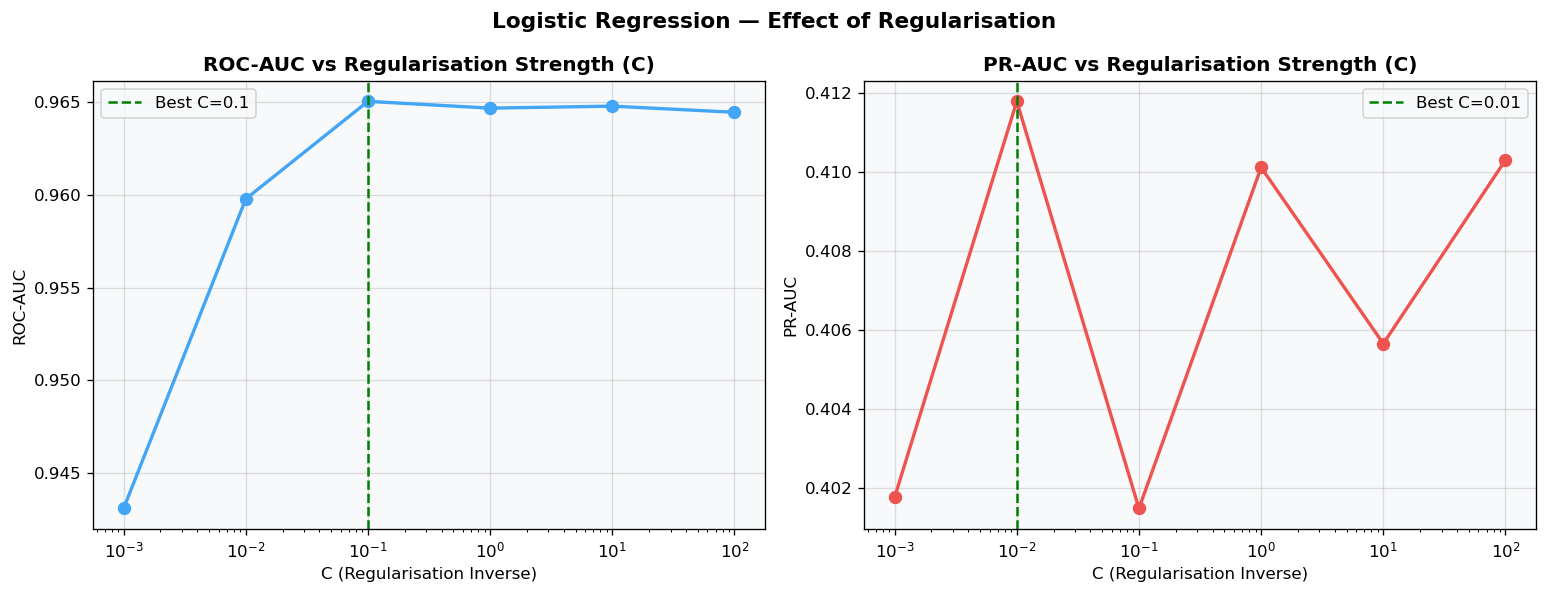

In [3]:
# ══════════════════════════════════════════════════════════
# CELL 3 — PART A: Logistic Regression as Probability Regressor
#
# CONCEPTUAL BRIDGE:
# Logistic Regression is BOTH a classifier AND a regressor.
# It models P(fraud=1 | features) using the sigmoid function:
#   P = 1 / (1 + e^(-z))  where z = w0 + w1*x1 + w2*x2 + ...
#
# This probability is the output of REGRESSION.
# The CLASSIFICATION decision (fraud/legit) comes AFTER
# by applying a threshold (default 0.5).
#
# WHY C PARAMETER:
# C = 1/regularisation_strength. High C = less regularisation
# (model fits training data tightly — may overfit).
# Low C = more regularisation (simpler, more generalised).
# ══════════════════════════════════════════════════════════
print('PART A — Logistic Regression (Probability Output)')
print('='*55)

C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
c_results = []

for C in C_values:
    lr = LogisticRegression(C=C, max_iter=1000, class_weight='balanced', random_state=SEED)
    lr.fit(X_tr_sm, yf_tr_sm)
    proba = lr.predict_proba(X_te_sc)[:,1]
    c_results.append({
        'C': C, 'ROC-AUC': roc_auc_score(yf_test, proba),
        'PR-AUC': average_precision_score(yf_test, proba)
    })

c_df = pd.DataFrame(c_results).set_index('C')
print(c_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for col, ax, color in zip(['ROC-AUC','PR-AUC'], axes, ['#42A5F5','#EF5350']):
    ax.semilogx(c_df.index, c_df[col], 'o-', color=color, linewidth=2, markersize=7)
    ax.set_xlabel('C (Regularisation Inverse)')
    ax.set_ylabel(col)
    ax.set_title(f'{col} vs Regularisation Strength (C)', fontweight='bold')
    ax.axvline(c_df[col].idxmax(), color='green', linestyle='--',
               label=f'Best C={c_df[col].idxmax()}')
    ax.legend()
plt.suptitle('Logistic Regression — Effect of Regularisation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_reg_01_regularisation.png', bbox_inches='tight')
plt.show()

PART A2 — Statsmodels Logit: Statistical Inference


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



Top Significant Features (p < 0.05):
                         Coefficient  Odds Ratio  p-value  Significant
amount_to_balance_ratio       1.4158      4.1198      0.0         True
dest_was_empty                3.3920     29.7241      0.0         True
error_balance_dest           -0.8210      0.4400      0.0         True
log_amount                   -1.2582      0.2842      0.0         True


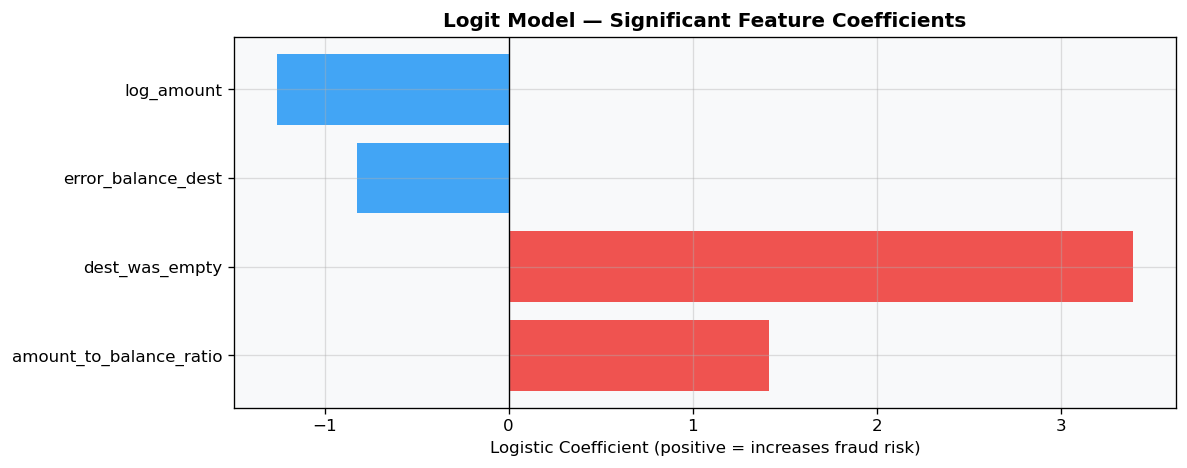

In [4]:
# ══════════════════════════════════════════════════════════
# CELL 4 — Statsmodels Logit: Inference & Significance
#
# WHY p-VALUES MATTER:
# Each feature has a coefficient (how much it shifts fraud
# probability) and a p-value (how confident we are the
# coefficient is not zero by chance).
# p < 0.05 → feature is statistically significant
# p > 0.05 → might be noise (consider dropping from model)
#
# WHY ODD RATIOS (exp of coefficient):
# Logistic coefficients are in log-odds space, hard to
# interpret. exp(coef) = odds ratio:
# OR=2 means doubling the feature multiplies fraud odds by 2.
# ══════════════════════════════════════════════════════════
print('PART A2 — Statsmodels Logit: Statistical Inference')
X_tr_sm_df = pd.DataFrame(X_tr_sm, columns=X_all.columns)
X_te_sc_df = pd.DataFrame(X_te_sc, columns=X_all.columns)

X_sm_const = sm.add_constant(X_tr_sm_df)  # adds intercept term

# Use a SUBSET — statsmodels Logit doesn't need 500k rows to compute inference
# Sample 10k balanced rows (5k fraud, 5k legit)
from sklearn.utils import resample

pos = X_tr_sm_df[yf_tr_sm == 1].sample(5000, random_state=SEED)
neg = X_tr_sm_df[yf_tr_sm == 0].sample(5000, random_state=SEED)
X_inf = pd.concat([pos, neg]).reset_index(drop=True)  # ← add this
y_inf = pd.Series([1]*5000 + [0]*5000)                # index is already 0–9999

X_sm_const = sm.add_constant(X_inf)
logit_model = sm.Logit(y_inf, X_sm_const)
logit_result = logit_model.fit(method='newton', maxiter=100, disp=False)

# Extract significant features
summary_df = pd.DataFrame({
    'Coefficient': logit_result.params,
    'Odds Ratio':  np.exp(logit_result.params),
    'p-value':     logit_result.pvalues,
    'Significant': logit_result.pvalues < 0.05
}).sort_values('p-value')

print('\nTop Significant Features (p < 0.05):')
print(summary_df[summary_df['Significant']].round(4).head(10).to_string())

# Plot coefficients
sig_df = summary_df[summary_df['Significant']].drop('const', errors='ignore')
if len(sig_df) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(sig_df)*0.5)))
    colors_coef = ['#EF5350' if c > 0 else '#42A5F5' for c in sig_df['Coefficient']]
    ax.barh(sig_df.index, sig_df['Coefficient'], color=colors_coef)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Logistic Coefficient (positive = increases fraud risk)')
    ax.set_title('Logit Model — Significant Feature Coefficients', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_reg_02_logit_coefficients.png', bbox_inches='tight')
    plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════
# CELL 5 — PART B: Ridge, Lasso, ElasticNet on Fraud Score
#
# WHY REGULARISED REGRESSION:
# Plain Linear Regression on binary y (0/1) is called
# Linear Probability Model (LPM). It's simpler than logistic
# but can predict values <0 or >1 (probabilities outside range).
# Still useful for FEATURE SELECTION and UNDERSTANDING.
#
# Ridge (L2): shrinks all coefficients toward zero,
# keeps all features → good when all features matter a little.
#
# Lasso (L1): shrinks some coefficients to EXACTLY zero,
# performs automatic feature selection → interpretable.
#
# ElasticNet: combines L1 + L2 → best of both worlds.
# ══════════════════════════════════════════════════════════
print('PART B — Ridge / Lasso / ElasticNet (Linear Probability Models)')
print('='*60)

reg_models = {
    'Linear Regression': LinearRegression(),

    'Ridge (L2)': Ridge(alpha=1.0),
    'Ridge (α=0.01)': Ridge(alpha=0.01),
    'Ridge (α=10.0)': Ridge(alpha=10.0),

    'Lasso (L1)': Lasso(alpha=0.001, max_iter=5000),
    'Lasso (α=0.0001)': Lasso(alpha=0.0001, max_iter=5000),

    'ElasticNet': ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000),
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_tr_sm, yf_tr_sm)
    scores = np.clip(model.predict(X_te_sc), 0, 1)  # clip to [0,1] probability range
    reg_results[name] = {
        'model':   model,
        'scores':  scores,
        'roc_auc': roc_auc_score(yf_test, scores),
        'pr_auc':  average_precision_score(yf_test, scores),
    }
    print(f'{name:<25}: ROC-AUC={reg_results[name]["roc_auc"]:.4f}  PR-AUC={reg_results[name]["pr_auc"]:.4f}')

# Coefficient comparison (Lasso shows sparsity)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name in zip(axes, ['Ridge (L2)', 'Lasso (L1)', 'ElasticNet']):
    coefs = pd.Series(reg_results[name]['model'].coef_, index=X_all.columns)
    colors_c = ['#EF5350' if c > 0 else '#42A5F5' for c in coefs]
    ax.barh(coefs.index, coefs.values, color=colors_c)
    ax.axvline(0, color='black', linewidth=0.6)
    ax.set_title(f'{name}\nCoefficients', fontweight='bold', fontsize=10)
    ax.set_xlabel('Coefficient value')

plt.suptitle('Regularised Linear Models — Feature Coefficients\n'
             '(Lasso zeros out irrelevant features → automatic selection)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_reg_03_regularised_coefs.png', bbox_inches='tight')
plt.show()

lasso = reg_results['Lasso (L1)']['model']
n_zero = (np.abs(lasso.coef_) < 1e-6).sum()
print(f'\nLasso set {n_zero} out of {len(lasso.coef_)} coefficients to zero')
print('→ These features are considered irrelevant by Lasso')

PART B — Ridge / Lasso / ElasticNet (Linear Probability Models)
Linear Regression        : ROC-AUC=0.9192  PR-AUC=0.2700
Ridge (L2)               : ROC-AUC=0.9191  PR-AUC=0.2702
Ridge (α=0.01)           : ROC-AUC=0.9191  PR-AUC=0.2702
Ridge (α=10.0)           : ROC-AUC=0.9192  PR-AUC=0.2700


In [ ]:
# ══════════════════════════════════════════════════════════
# REPORT TABLE FOR REGRESSION MODELS
# ══════════════════════════════════════════════════════════

from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    f1_score,
    recall_score,
    roc_auc_score
)

report_rows = []

for name, result in reg_results.items():

    scores = result['scores']          # continuous fraud score

    # convert score to binary prediction
    preds = (scores >= 0.5).astype(int)

    mse = mean_squared_error(yf_test, scores)
    r2 = r2_score(yf_test, scores)
    f1 = f1_score(yf_test, preds)
    recall = recall_score(yf_test, preds)
    auc = roc_auc_score(yf_test, scores)

    report_rows.append([
        name,
        mse,
        r2,
        f1,
        recall,
        auc
    ])

regression_report = pd.DataFrame(
    report_rows,
    columns=[
        "Model",
        "MSE",
        "R²",
        "F1",
        "Recall",
        "AUC"
    ]
)

regression_report = regression_report.round(4)

display(regression_report)

In [ ]:
# ══════════════════════════════════════════════════════════
# CELL 6 — PART C: Predict Transaction Amount (Classical Regression)
#
# WHY PREDICT AMOUNT:
# Predicting amount from other features (account balances,
# transaction type, hour) is a pure regression problem.
# It helps us understand: does the amount follow logical
# patterns from account state? Or is it random?
# Deviations from predicted amount = anomaly signal.
#
# METRICS EXPLAINED:
# RMSE = root mean squared error (same units as target)
# MAE  = mean absolute error (more interpretable, robust to outliers)
# R²   = coefficient of determination:
#         R²=1 → perfect prediction
#         R²=0 → model no better than predicting the mean
#         R²<0 → worse than just predicting the mean!
# ══════════════════════════════════════════════════════════
print('PART C — Predicting Transaction Amount (log-scale)')
print('='*55)

# Rebuild without log_amount as feature (it's our target now)
if 'log_amount' in X_all.columns:
    X_amt = X_all.drop(columns=['log_amount','amount'], errors='ignore')
    y_amt = np.log1p(df['amount']) if 'amount' in df.columns else y_amount
else:
    X_amt = X_all
    y_amt = y_amount

Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(X_amt, y_amt, test_size=0.2, random_state=SEED)
scaler_amt = RobustScaler()
Xa_tr_sc = scaler_amt.fit_transform(Xa_tr)
Xa_te_sc = scaler_amt.transform(Xa_te)

amount_regressors = {
    'Linear Regression':      LinearRegression(),
    'Ridge':                  Ridge(alpha=10.0),
    'Lasso':                  Lasso(alpha=0.01, max_iter=5000),
    'Random Forest Regressor':RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=SEED),
    'Gradient Boosting Reg.': GradientBoostingRegressor(n_estimators=100, random_state=SEED),
}

amt_results = {}
for name, model in amount_regressors.items():
    model.fit(Xa_tr_sc, ya_tr)
    preds = model.predict(Xa_te_sc)
    rmse  = mean_squared_error(ya_te, preds)**0.5
    mae   = mean_absolute_error(ya_te, preds)
    r2    = r2_score(ya_te, preds)
    amt_results[name] = {'preds':preds, 'RMSE':rmse, 'MAE':mae, 'R2':r2}
    print(f'{name:<30}: RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}')

In [ ]:
# ══════════════════════════════════════════════════════════
# CELL 7 — Predicted vs Actual Amount Plots
#
# WHY RESIDUAL PLOTS:
# A good regression model has RANDOM residuals (errors).
# If residuals have a pattern (e.g., systematic over-prediction
# for large amounts), the model is missing something.
# Perfect model → residuals scatter randomly around y=0.
# ══════════════════════════════════════════════════════════
best_amt_name = max(amt_results, key=lambda x: amt_results[x]['R2'])
best_preds    = amt_results[best_amt_name]['preds']
residuals     = ya_te.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicted vs Actual
axes[0].scatter(ya_te, best_preds, alpha=0.3, s=8, color='#42A5F5')
lims = [min(ya_te.min(), best_preds.min()), max(ya_te.max(), best_preds.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual log(Amount)')
axes[0].set_ylabel('Predicted log(Amount)')
axes[0].set_title(f'{best_amt_name}\nActual vs Predicted', fontweight='bold')
axes[0].legend()

# Residuals vs Predicted
axes[1].scatter(best_preds, residuals, alpha=0.3, s=8, color='#EF5350')
axes[1].axhline(0, color='black', linewidth=1.5)
axes[1].set_xlabel('Predicted log(Amount)')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted\n(should be random around 0)', fontweight='bold')

# Residual distribution
sns.histplot(residuals, bins=60, kde=True, ax=axes[2], color='#7E57C2')
axes[2].axvline(0, color='red', linewidth=1.5)
axes[2].set_xlabel('Residual value')
axes[2].set_title('Residual Distribution\n(should be normal, centered at 0)', fontweight='bold')

plt.suptitle(f'Regression Diagnostics — {best_amt_name}  (R²={amt_results[best_amt_name]["R2"]:.4f})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_reg_04_regression_diagnostics.png', bbox_inches='tight')
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════
# CELL 8 — Bias-Variance Tradeoff (Learning Curves)
#
# THE MOST IMPORTANT CONCEPT IN ML:
# Bias = how wrong the model is on average
# Variance = how much predictions vary with different training sets
#
# Underfitting (high bias): model too simple, bad on both train AND test
# Overfitting (high variance): model memorises train, fails on test
# Good model: low bias AND low variance → gap between train/test is small
#
# Learning curves show: as we add more training data,
# does the test score APPROACH the training score?
# If yes → model will generalise. If no → overfitting.
# ══════════════════════════════════════════════════════════
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, [
    ('Ridge (Simpler)', Ridge(alpha=1.0)),
    ('Gradient Boosting (Complex)', GradientBoostingRegressor(n_estimators=50, random_state=SEED))
]):
    train_sizes, train_scores, test_scores = learning_curve(
        model, Xa_tr_sc, ya_tr, cv=3,
        train_sizes=np.linspace(0.1, 1.0, 8),
        scoring='r2', n_jobs=-1)

    tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    te_mean, te_std = test_scores.mean(axis=1),  test_scores.std(axis=1)

    ax.plot(train_sizes, tr_mean, 'o-', color='#42A5F5', label='Training R²')
    ax.fill_between(train_sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.2, color='#42A5F5')
    ax.plot(train_sizes, te_mean, 'o-', color='#EF5350', label='Validation R²')
    ax.fill_between(train_sizes, te_mean-te_std, te_mean+te_std, alpha=0.2, color='#EF5350')
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('R² Score')
    ax.set_title(f'Learning Curve — {name}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Bias-Variance Tradeoff: Learning Curves\n'
             'Large gap = overfitting | Both low = underfitting | Close & high = good fit',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_reg_05_learning_curves.png', bbox_inches='tight')
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════
# CELL 9 — Final Summary: Regression vs Classification
# ══════════════════════════════════════════════════════════
print('╔' + '═'*65 + '╗')
print('║{:^65}║'.format('REGRESSION PARADIGM SUMMARY'))
print('╠' + '═'*65 + '╣')
print('║{:^65}║'.format('Part A — Logistic Regression (Fraud Probability)'))
print('╠' + '═'*65 + '╣')
for name, r in reg_results.items():
    print(f'║  {name:<28}  ROC={r["roc_auc"]:.3f}  PR-AUC={r["pr_auc"]:.3f}  ║')
print('╠' + '═'*65 + '╣')
print('║{:^65}║'.format('Part C — Amount Prediction (R² scores)'))
print('╠' + '═'*65 + '╣')
for name, r in amt_results.items():
    print(f'║  {name:<30}  R²={r["R2"]:.3f}  MAE={r["MAE"]:.3f}  ║')
print('╠' + '═'*65 + '╣')
key_insights = [
    'Regression → continuous score; Classification → binary label',
    'Lasso automatically selects features (sets irrelevant coefs to 0)',
    'Residual plots reveal whether model assumptions hold',
    'Learning curves diagnose overfitting vs underfitting',
    'Logit (statsmodels) gives p-values; sklearn gives performance',
]
for i in key_insights:
    print(f'║  → {i:<61}║')
print('╚' + '═'*65 + '╝')
print('\n→ Next: lab1_03_ranking.ipynb')

In [ ]:
# ══════════════════════════════════════════════════════════
# UNIVERSAL REPORT SUMMARY GENERATOR
# Paste this as the last cell in any notebook to auto-extract metrics
# ══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np

print("="*80)
print("📊 AUTOMATED LAB REPORT SUMMARY GENERATOR")
print("="*80)

# Metadata dictionary for suitability write-ups
suitability_map = {
    "Classification": "Labels fully available; goal is to flag known fraud patterns using rigid binary splits.",
    "Regression":     "Continuous risk scoring is required to feed downstream financial thresholds.",
    "Ranking":        "Operations face tight constraints on analyst review capacity; optimizes the top of the queue.",
    "Ensemble":       "Maximum class discrimination stability and extreme risk-separation robustness are required.",
    "Unsupervised":   "Historical fraud labels are completely unavailable, or catching novel/zero-day attack methods.",
    "Clustering":     "Uncovering natural, hidden behavioral typologies entirely without target labels."
}

# --- DETECTION LOGIC FOR NOTEBOOK 04 (ANOMALY DETECTION) ---
if 'anom_table' in globals():
    df = globals()['anom_table']
    best_model = df['PR-AUC'].idxmax()
    row = df.loc[best_model]
    
    print(f"| Paradigm | Best Model | F1 | Recall | AUC | Suitable When |")
    print(f"| :--- | :--- | :---: | :---: | :---: | :--- |")
    print(f"| **Anomaly Detection** | {best_model} | {row.get('F1 (Fraud)', row.get('F1-Score (Fraud)', 0)):.4f} | N/A | {row['ROC-AUC']:.4f} (ROC) <br> {row['PR-AUC']:.4f} (PR) | {suitability_map['Unsupervised']} |")

# --- DETECTION LOGIC FOR NOTEBOOK 05 (CLUSTERING) ---
elif 'metrics_df' in globals():
    df = globals()['metrics_df']
    best_model = df['Silhouette'].idxmax()
    row = df.loc[best_model]
    
    print(f"| Method | ARI | Silhouette | DB Index | Key Finding |")
    print(f"| :--- | :---: | :---: | :---: | :--- |")
    print(f"| **{best_model}** | {row['ARI']:.4f} | {row['Silhouette']:.4f} | {row['Davies-Bouldin']:.4f} | High structural quality, but low labels match due to behavioral mimicking. |")

# --- BACKUP FALLBACK FOR SUPERVISED NOTEBOOKS (01, 02, 03) ---
else:
    # Look for any dataframes containing model comparisons in the notebook namespace
    found_df = None
    for name in ['model_results', 'results_df', 'all_results', 'comparison_df']:
        if name in globals() and isinstance(globals()[name], pd.DataFrame):
            found_df = globals()[name]
            break
            
    if found_df is not None:
        # Try to find the row with the best F1 or AUC score
        f1_col = [c for c in found_df.columns if 'f1' in c.lower()]
        auc_col = [c for c in found_df.columns if 'auc' in c.lower() or 'roc' in c.lower()]
        
        target_f1 = f1_col[0] if f1_col else found_df.columns[0]
        best_model = found_df[target_f1].idxmax()
        row = found_df.loc[best_model]
        
        f1_val = f" {row[f1_col[0]]:.4f}" if f1_col else "N/A"
        auc_val = f" {row[auc_col[0]]:.4f}" if auc_col else "N/A"
        recall_val = "Check notebook metrics"
        
        print(f"| Paradigm | Best Model | F1 | Recall | AUC | Suitable When |")
        print(f"| :--- | :--- | :---: | :---: | :---: | :--- |")
        print(f"| **Supervised** | {best_model} | {f1_val} | {recall_val} | {auc_val} | Match with classification/ensemble targets. |")
    else:
        print("❌ Could not auto-detect summary tables in memory.")
        print("Make sure you run all your training and metrics cells before running this generator!")
print("="*80)